In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

curr_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(curr_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
sys.path.append(root_dir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/hopper'
model_dir = '../../../models/mujoco/hopper'
result_dir = '../../../results/mujoco/hopper'

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'hopper',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '11',
        '--act_ndim', '3',
        '--target_ndim', '11',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '512',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '500',
        '--patience', '50',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = torch.zeros(args.target_ndim)

In [3]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[4]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 65536


In [4]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_mujoco.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

read timeseries shape is torch.Size([50, 918, 14])


In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters: {nparam/1e6}M')

number of trainable parameters: 1.226524M


### Train nominal model

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
read timeseries shape is torch.Size([31732, 48, 14])
	epoch 1 losses: train=0.844952, valid=0.441254, test=0.445998
	validation loss decreased (inf -> 0.441254), saving model ...
	epoch 2 losses: train=0.306435, valid=0.234178, test=0.237071
	validation loss decreased (0.441254 -> 0.234178), saving model ...
	epoch 3 losses: train=0.188091, valid=0.147499, test=0.149588
	validation loss decreased (0.234178 -> 0.147499), saving model ...
	epoch 4 losses: train=0.119064, valid=0.092413, test=0.093788
	validation loss decreased (0.147499 -> 0.092413), saving model ...
	epoch 5 losses: train=0.077458, valid=0.066529, test=0.067666
	validation loss decreased (0.092413 -> 0.066529), saving model ...
	epoch 6 losses: train=0.058603, valid=0.052515, test=0.053487
	validation loss decreased (0.066529 -> 0.052515), saving model ...
	epoch 7 losses: train=0.049281, valid=0.045935, test=0.046551
	validation loss decreased (0.052515 -> 0.045935), saving model ...
	epoc

In [7]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

read timeseries shape is torch.Size([31732, 48, 14])


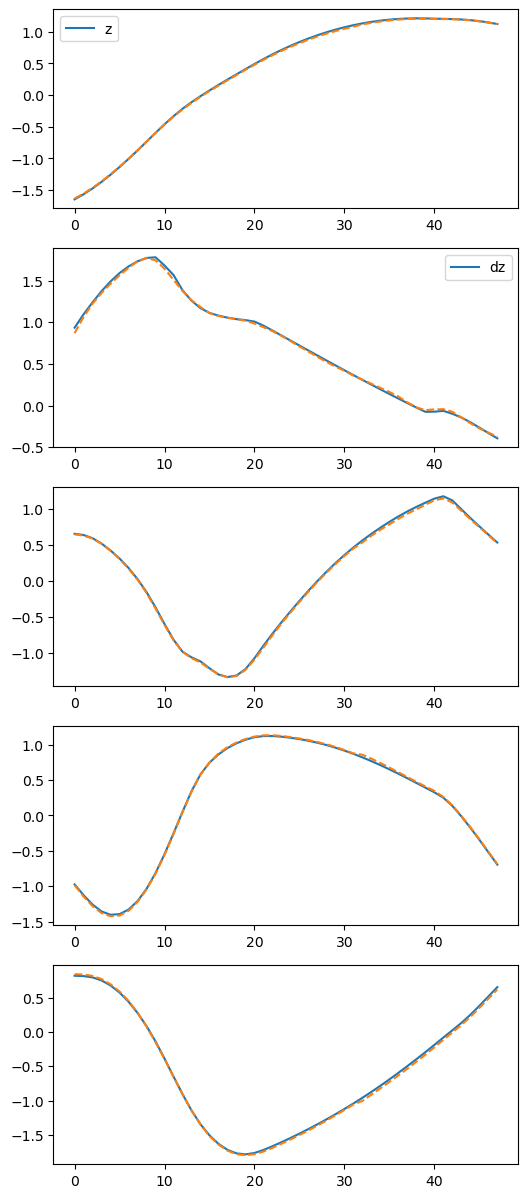

In [8]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,15))

        plt.subplot(5,1,1)
        plt.plot(true[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(5,1,2)
        plt.plot(true[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(5,1,3)
        plt.plot(true[jdata, :, 1])
        plt.plot(mean_nom[0, :, 1], linestyle='dashed')

        plt.subplot(5,1,4)
        plt.plot(true[jdata, :, 2])
        plt.plot(mean_nom[0, :, 2], linestyle='dashed')

        plt.subplot(5,1,5)
        plt.plot(true[jdata, :, 3])
        plt.plot(mean_nom[0, :, 3], linestyle='dashed')

        plt.show()

        break

### Train nominal uncertainty

In [9]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
read timeseries shape is torch.Size([31732, 48, 14])
read timeseries shape is torch.Size([11818, 48, 14])
	epoch 1 losses: train=0.135947, valid=0.076951, test=0.079193
	validation loss decreased (inf -> 0.076951), saving model ...
	epoch 2 losses: train=0.075447, valid=0.072332, test=0.074758
	validation loss decreased (0.076951 -> 0.072332), saving model ...
	epoch 3 losses: train=0.058600, valid=0.048440, test=0.048323
	validation loss decreased (0.072332 -> 0.048440), saving model ...
	epoch 4 losses: train=0.040591, valid=0.032220, test=0.031933
	validation loss decreased (0.048440 -> 0.032220), saving model ...
	epoch 5 losses: train=0.027095, valid=0.025283, test=0.024316
	validation loss decreased (0.032220 -> 0.025283), saving model ...
	epoch 6 losses: train=0.023166, valid=0.023042, test=0.021884
	validation loss decreased (0.025283 -> 0.023042), saving model ...
	epoch 7 losses: train=0.021065, valid=0.020879, test=0.019436
	validation l

In [10]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

read timeseries shape is torch.Size([31732, 48, 14])
read timeseries shape is torch.Size([11818, 48, 14])


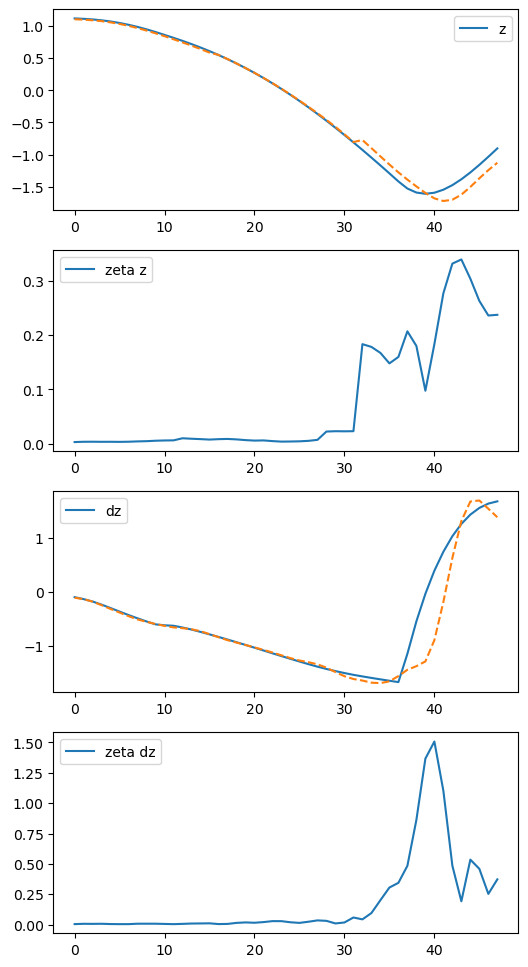

In [11]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta z')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(zeta_nom[0, :, 6], label='zeta dz')
        plt.legend()

        plt.show()

        break

### Train excursion model

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
read timeseries shape is torch.Size([11818, 48, 14])
	epoch 1 losses: train=0.973588, valid=0.936273, test=0.943789
	validation loss decreased (inf -> 0.936273), saving model ...
	epoch 2 losses: train=0.887651, valid=0.847471, test=0.855438
	validation loss decreased (0.936273 -> 0.847471), saving model ...
	epoch 3 losses: train=0.792579, valid=0.746853, test=0.751425
	validation loss decreased (0.847471 -> 0.746853), saving model ...
	epoch 4 losses: train=0.655688, valid=0.560531, test=0.566737
	validation loss decreased (0.746853 -> 0.560531), saving model ...
	epoch 5 losses: train=0.507127, valid=0.427783, test=0.433262
	validation loss decreased (0.560531 -> 0.427783), saving model ...
	epoch 6 losses: train=0.358219, valid=0.289612, test=0.293357
	validation loss decreased (0.427783 -> 0.289612), saving model ...
	epoch 7 losses: train=0.267858, valid=0.233948, test=0.235932
	validation loss decreased (0.289612 -> 0.233948), saving model ...
	ep

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

read timeseries shape is torch.Size([11818, 48, 14])


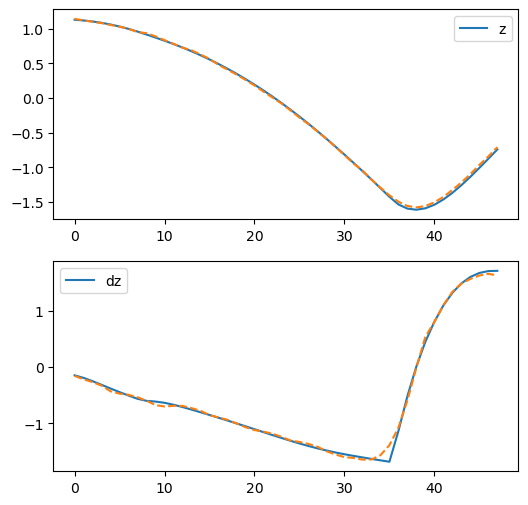

In [14]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_exc[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.show()

        break

### Train excursion uncertainty

In [15]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
read timeseries shape is torch.Size([31732, 48, 14])
read timeseries shape is torch.Size([11818, 48, 14])
	epoch 1 losses: train=0.340489, valid=0.250191, test=0.252050
	validation loss decreased (inf -> 0.250191), saving model ...
	epoch 2 losses: train=0.206035, valid=0.130811, test=0.130713
	validation loss decreased (0.250191 -> 0.130811), saving model ...
	epoch 3 losses: train=0.109739, valid=0.094943, test=0.094454
	validation loss decreased (0.130811 -> 0.094943), saving model ...
	epoch 4 losses: train=0.085945, valid=0.075762, test=0.075512
	validation loss decreased (0.094943 -> 0.075762), saving model ...
	epoch 5 losses: train=0.066894, valid=0.061032, test=0.060686
	validation loss decreased (0.075762 -> 0.061032), saving model ...
	epoch 6 losses: train=0.056859, valid=0.053673, test=0.053245
	validation loss decreased (0.061032 -> 0.053673), saving model ...
	epoch 7 losses: train=0.050465, valid=0.047098, test=0.046683
	validation

In [16]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

read timeseries shape is torch.Size([31732, 48, 14])
read timeseries shape is torch.Size([11818, 48, 14])


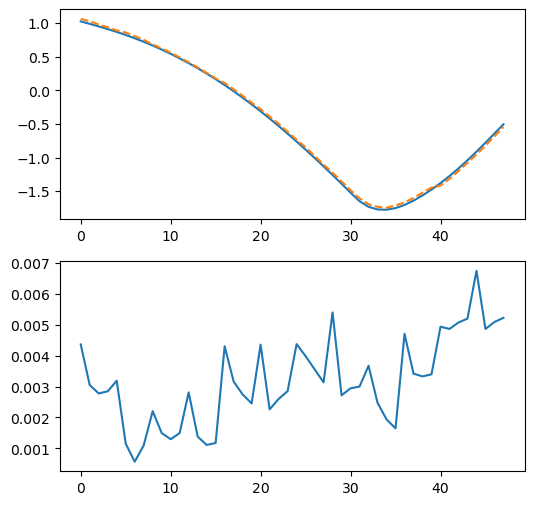

In [17]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc
        zeta_exc = model_o.zeta_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_exc[0, :, :1])

        plt.show()

        break

## Evaluate KIND blending

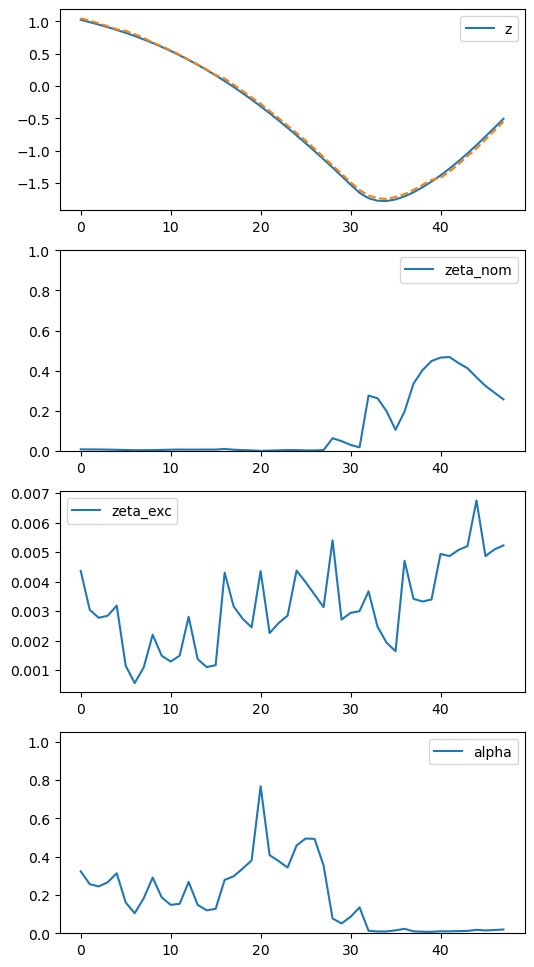

In [18]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pred = model_o.blend
        zeta_nom = model_o.zeta_nom
        zeta_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(pred[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(zeta_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break